# 07 — Florence-2 Auto-Annotation (M_auto prep)

Runs Florence-2 base `<DENSE_REGION_CAPTION>` over all Flickr30k **train** images
and saves `auto_annotations.json` to Google Drive.

| Cell | Purpose |
|------|---------|
| 0 | Install deps |
| 1 | Imports |
| 2 | Mount Drive + load Flickr30k |
| 3 | Download + patch Florence-2 |
| 4 | Run annotation (resume-safe) |
| 5 | Verify output |

**Run once.** After this notebook completes, `graft-training.ipynb` will load
`auto_annotations.json` from Drive automatically when running the M_auto cell.

**Time:** ~45–60 min on L4 GPU (greedy decoding, float16, ~29k images).

**Resume-safe:** re-running cell 4 skips already-annotated images and picks up
where it left off.

In [1]:
# ── 0. Install dependencies ──────────────────────────────────────────────────
import subprocess, sys
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'transformers==4.38.2',   # last version known-good with Florence-2
    'datasets', 'huggingface_hub', 'tqdm', 'Pillow',
], check=True)
print('Dependencies installed.')

Dependencies installed.


In [2]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import gc, io, json, os, re, shutil, sys, zipfile
from pathlib import Path

import torch
from PIL import Image as PILImage
from tqdm.auto import tqdm
from datasets import load_dataset
from huggingface_hub import HfApi, hf_hub_download, snapshot_download
from transformers import AutoProcessor, AutoModelForCausalLM

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB')

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
VRAM free: 39.4 GB


In [3]:
# ── 2. Mount Drive + load Flickr30k ──────────────────────────────────────────
# Reuses the same Drive cache created by graft-training.ipynb cell 3.
# If the cache zip doesn't exist yet, run graft-training.ipynb cell 3 first
# (it downloads Flickr30k parquets + Entities annotations and zips to Drive).

from google.colab import drive

GDRIVE_ROOT = Path('/content/drive')
drive.mount(str(GDRIVE_ROOT))

GDRIVE_ZIP  = GDRIVE_ROOT / 'MyDrive' / 'region-grounded-data' / 'flickr30k_full.zip'
LOCAL_DATA  = Path('data/flickr30k')
PQ_DIR      = LOCAL_DATA / 'parquet'

if GDRIVE_ZIP.exists():
    sz_gb = GDRIVE_ZIP.stat().st_size / 1e9
    print(f'Drive cache found ({sz_gb:.1f} GB). Extracting parquets...')
    LOCAL_DATA.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(str(GDRIVE_ZIP)) as zf:
        # Only extract parquet shards — we don't need Entities XMLs here
        members = [m for m in zf.namelist() if 'parquet' in m]
        zf.extractall('.', members=members)
    print(f'Extracted {len(members)} parquet shards.')
else:
    # First-time: download parquets directly
    import urllib.request
    PQ_DIR.mkdir(parents=True, exist_ok=True)
    HF_TOKEN = os.environ.get('HF_TOKEN') or __import__('getpass').getpass('HF token: ')
    os.environ['HF_TOKEN'] = HF_TOKEN
    REPO_ID  = 'nlphuji/flickr30k'
    api      = HfApi(token=HF_TOKEN)
    pq_names = sorted(
        f for f in api.list_repo_files(REPO_ID, repo_type='dataset',
                                        revision='refs/convert/parquet')
        if f.endswith('.parquet')
    )
    print(f'Downloading {len(pq_names)} parquet shard(s)...')
    for fname in pq_names:
        cached = hf_hub_download(
            repo_id=REPO_ID, filename=fname, repo_type='dataset',
            revision='refs/convert/parquet', token=HF_TOKEN,
        )
        shutil.copy(cached, PQ_DIR / Path(fname).name)
    print('Parquet shards downloaded.')

local_pq = sorted(str(f) for f in PQ_DIR.glob('*.parquet'))
hf_data  = load_dataset('parquet', data_files={'data': local_pq})['data']
train_rows = [r for r in hf_data if r['split'] == 'train']
print(f'Flickr30k total rows: {len(hf_data):,}')
print(f'Train rows: {len(train_rows):,}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive cache found (4.4 GB). Extracting parquets...
Extracted 9 parquet shards.


Generating data split: 0 examples [00:00, ? examples/s]

Flickr30k total rows: 31,014
Train rows: 29,000


In [4]:
# ── 3. Download + patch Florence-2 ───────────────────────────────────────────
# Downloads Florence-2 base (~885 MB) and stubs out the flash_attn import
# that is not available in the base Colab environment.

FLORENCE_LOCAL = Path('florence2_local')

if not FLORENCE_LOCAL.exists():
    print('Downloading Florence-2 base (~885 MB)...')
    snapshot_download(
        repo_id='microsoft/Florence-2-base',
        local_dir=str(FLORENCE_LOCAL),
        ignore_patterns=['*.msgpack', '*.h5'],
    )
    # Stub out flash_attn import
    mod_path = FLORENCE_LOCAL / 'modeling_florence2.py'
    src_txt  = mod_path.read_text()
    src_txt  = re.sub(
        r'from flash_attn[^\n]*',
        'pass  # flash_attn stubbed',
        src_txt,
    )
    mod_path.write_text(src_txt)
    print('Downloaded and patched.')
else:
    print('Florence-2 already present locally.')

fl_proc  = AutoProcessor.from_pretrained(str(FLORENCE_LOCAL), trust_remote_code=True)
fl_model = AutoModelForCausalLM.from_pretrained(
    str(FLORENCE_LOCAL),
    trust_remote_code=True,
    torch_dtype=torch.float16,
).to(DEVICE).eval()
print(f'Florence-2 loaded on {DEVICE}.')
if DEVICE == 'cuda':
    print(f'VRAM after load: {(torch.cuda.mem_get_info()[1]-torch.cuda.mem_get_info()[0])/1e9:.1f} GB used')

Florence-2 already present locally.
Florence-2 loaded on cuda.
VRAM after load: 3.5 GB used


In [5]:
import time

# ── 4. Run annotation — batched, resume-safe ─────────────────────────────────
# Output: auto_annotations.json
#   {filename: {"bboxes": [[x1,y1,x2,y2],...], "labels": [...]}}
# Bboxes are absolute pixel coords of the original PIL image.
# Saves to Drive every SAVE_EVERY images. Safe to interrupt and re-run.
#
# Batched inference: BATCH_SIZE images per forward pass keeps the A100 busy.
# A100 40 GB (0.9 GB used by model) → batch_size=8 uses ~4 GB, very safe.
# Raise to 16 for more throughput; lower to 4 if you get OOM.

GDRIVE_ANN = GDRIVE_ROOT / 'MyDrive' / 'region-grounded-data' / 'auto_annotations.json'
LOCAL_ANN  = LOCAL_DATA / 'auto_annotations.json'
SAVE_EVERY = 500
TASK       = '<DENSE_REGION_CAPTION>'
BATCH_SIZE = 8
MAX_TOKENS = 128    # Florence-2 dense captions are short; 128 is never hit

# Resume from Drive if available
if GDRIVE_ANN.exists():
    shutil.copy(str(GDRIVE_ANN), str(LOCAL_ANN))
    with open(LOCAL_ANN) as f:
        auto_ann = json.load(f)
    print(f'Resumed: {len(auto_ann):,} images already annotated.')
else:
    auto_ann = {}
    print('Starting fresh.')

todo = [r for r in train_rows if r['filename'] not in auto_ann]
print(f'Remaining: {len(todo):,} / {len(train_rows):,} images')

def decode_pil(row):
    img_field = row['image']
    if isinstance(img_field, PILImage.Image):
        return img_field.convert('RGB')
    return PILImage.open(io.BytesIO(img_field['bytes'])).convert('RGB')

n_done_at_last_save = len(auto_ann)
_checkpoint_t = time.time()

for batch_start in tqdm(range(0, len(todo), BATCH_SIZE), desc='Florence-2'):
    batch_rows = todo[batch_start : batch_start + BATCH_SIZE]
    pils       = [decode_pil(r) for r in batch_rows]

    inputs = fl_proc(
        text           = [TASK] * len(pils),
        images         = pils,
        return_tensors = 'pt',
        padding        = True,
    ).to(DEVICE, torch.float16)

    with torch.no_grad():
        ids = fl_model.generate(
            input_ids      = inputs['input_ids'],
            pixel_values   = inputs['pixel_values'],
            attention_mask = inputs.get('attention_mask'),
            max_new_tokens = MAX_TOKENS,
            num_beams      = 1,
            do_sample      = False,
        )

    texts = fl_proc.batch_decode(ids, skip_special_tokens=False)
    for text, pil, row in zip(texts, pils, batch_rows):
        parsed = fl_proc.post_process_generation(
            text, task=TASK, image_size=(pil.width, pil.height)
        )
        result = parsed[TASK]
        auto_ann[row['filename']] = {
            'bboxes': result['bboxes'],
            'labels': result['labels'],
        }

    # Save whenever we cross a SAVE_EVERY boundary
    if len(auto_ann) // SAVE_EVERY > n_done_at_last_save // SAVE_EVERY:
        LOCAL_ANN.parent.mkdir(parents=True, exist_ok=True)
        with open(LOCAL_ANN, 'w') as f:
            json.dump(auto_ann, f)
        shutil.copy(str(LOCAL_ANN), str(GDRIVE_ANN))
        _elapsed = time.time() - _checkpoint_t
        _remaining = len(todo) - (len(auto_ann) - (len(train_rows) - len(todo)))
        _eta_min = _remaining / SAVE_EVERY * _elapsed / 60
        print(f'  checkpoint: {len(auto_ann):,} done | last 500 in {_elapsed:.0f}s | ETA ~{_eta_min:.0f} min')
        n_done_at_last_save = len(auto_ann)
        _checkpoint_t = time.time()

# Final save
LOCAL_ANN.parent.mkdir(parents=True, exist_ok=True)
with open(LOCAL_ANN, 'w') as f:
    json.dump(auto_ann, f)
shutil.copy(str(LOCAL_ANN), str(GDRIVE_ANN))
print(f'\nSaved to {GDRIVE_ANN}')

n_reg = sum(len(v['bboxes']) for v in auto_ann.values())
print(f'{len(auto_ann):,} images annotated')
print(f'{n_reg:,} total regions ({n_reg/len(auto_ann):.1f} per image avg)')


Resumed: 29,000 images already annotated.
Remaining: 0 / 29,000 images


Florence-2: 0it [00:00, ?it/s]


Saved to /content/drive/MyDrive/region-grounded-data/auto_annotations.json
29,000 images annotated
283,427 total regions (9.8 per image avg)


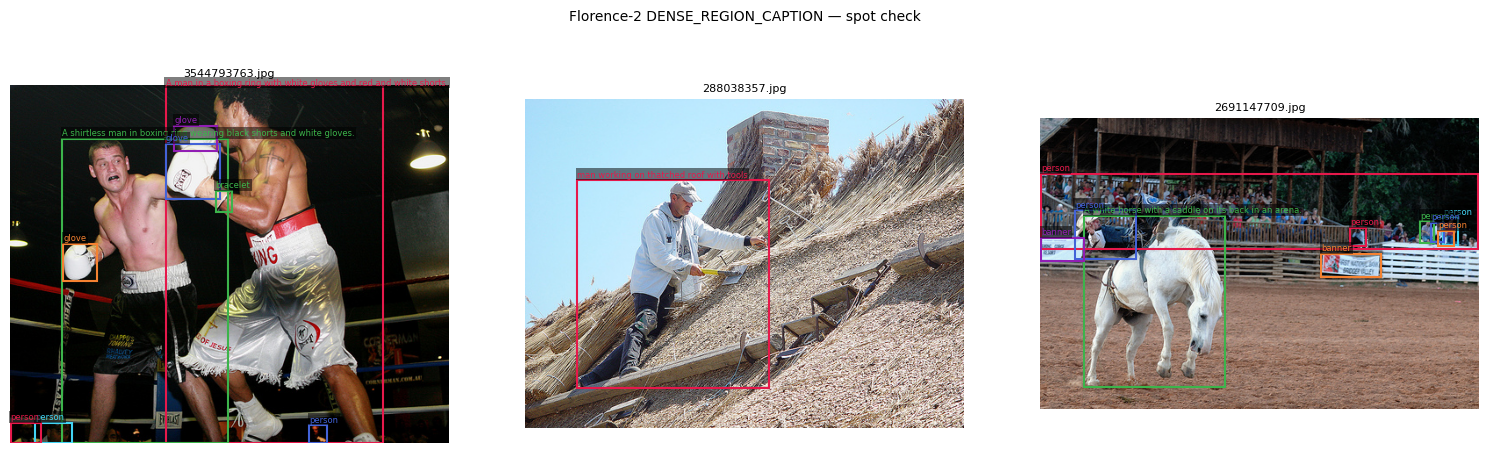

Verification complete. auto_annotations.json is ready for graft-training.ipynb.


In [6]:
# ── 5. Verify output ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random

# Spot-check 3 random images
samples = random.sample(list(auto_ann.items()), 3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
COLORS = ['#e6194b','#3cb44b','#4363d8','#f58231','#911eb4','#42d4f4']

for ax, (fname, ann) in zip(axes, samples):
    # Find the PIL image
    row = next(r for r in train_rows if r['filename'] == fname)
    img_field = row['image']
    if isinstance(img_field, PILImage.Image):
        pil = img_field.convert('RGB')
    else:
        pil = PILImage.open(io.BytesIO(img_field['bytes'])).convert('RGB')

    ax.imshow(pil)
    ax.set_title(fname, fontsize=8)
    ax.axis('off')

    for i, (bbox, label) in enumerate(zip(ann['bboxes'], ann['labels'])):
        x1, y1, x2, y2 = bbox
        color = COLORS[i % len(COLORS)]
        rect  = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                    linewidth=1.5, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, max(y1-4, 0), label, fontsize=6, color=color,
                bbox=dict(facecolor='black', alpha=0.5, pad=1, edgecolor='none'))

plt.suptitle('Florence-2 DENSE_REGION_CAPTION — spot check', fontsize=10)
plt.tight_layout()
plt.show()
print('Verification complete. auto_annotations.json is ready for graft-training.ipynb.')